#### Deep Learning Facial Recognition using PCA Features
Python notebooks cannot be run due to unavailable data.

This notebook extends the PCA-based facial recognition pipeline by introducing a convolutional neural network for facial classification.

1. Apply the same preprocessing stages used in the PCA implementation:
    - grayscale conversion
    - resizing and scaling
    - normalization
    - rotation augmentation
    -Haar Cascade face detection
2. Perform PCA-based dimensionality reduction on detected facial images
3. Train a CNN using PCA-transformed feature representations
4. Validate recognition performance using still-image facial classification tasks

In [ ]:
#import statements
from matplotlib import pyplot
from matplotlib.image import imread
import pandas as pd
import os
import sys
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from keras.layers import Flatten
from sklearn.decomposition import PCA
from tensorflow.keras.optimizers import SGD
from sklearn.model_selection import train_test_split
from keras.preprocessing.image import ImageDataGenerator
import cv2
import zipfile
import numpy as np
from tensorflow.keras.applications.resnet50 import ResNet50
from math import sin, cos, radians
import random
%matplotlib inline

In [2]:
import tensorflow as tf
print(tf.test.gpu_device_name())

/device:GPU:0


In [3]:
#ALLOWS ROTATION
def face_detection(img):
    settings = {
      'scaleFactor': 1.3,  
      #In a group photo, there may be some faces which are near the camera than others. Naturally, such 
      #faces would appear more prominent than the ones behind. This factor compensates for that.
      'minNeighbors':4 , #4 
      # Parameter specifying how many neighbors each candidate rectangle should have to retain it.
      'minSize': (50, 50), #50x50
      'flags': cv2.CASCADE_SCALE_IMAGE
      }

    face = cv2.CascadeClassifier(cv2.data.haarcascades +"haarcascade_frontalface_alt2.xml")

    for angle in [0, -25, 25]:
        rimg = rotate_image(img, angle)
        detected = face.detectMultiScale(rimg, **settings)
        if len(detected):
            detected = [rotate_point(detected[-1], img, -angle)]
            break

  # Make a copy as we don't want to draw on the original image:
    for x, y, w, h in detected[-1:]:
        #cv2.rectangle(img, (x, y), (x+w, y+h), (255,0,0), 2)
        img = img[y:y+h, x:x+w]
        #cv2_imshow(img)
        #cv2.waitKey()

    return img

In [4]:
def rotate_image(image, angle):
    if angle == 0: return image
    height, width = image.shape[:2]
    rot_mat = cv2.getRotationMatrix2D((width/2, height/2), angle, 0.9)
    result = cv2.warpAffine(image, rot_mat, (width, height), flags=cv2.INTER_LINEAR)
    return result

def rotate_point(pos, img, angle):
    if angle == 0: return pos
    x = pos[0] - img.shape[1]*0.4
    y = pos[1] - img.shape[0]*0.4
    newx = x*cos(radians(angle)) + y*sin(radians(angle)) + img.shape[1]*0.4
    newy = -x*sin(radians(angle)) + y*cos(radians(angle)) + img.shape[0]*0.4
    return int(newx), int(newy), pos[2], pos[3]

In [5]:
from numpy.random import seed
#to ensure reproducibility 
seed(1)
tf.random.set_seed(2)

# USING MLP

In [6]:
c = 0
angle_list = [15, -15, 30, -30, 15, -15]
faces = {}
dim = (300, 250) #height,width are from 100x100 to 300x250
#Reading images - 
folder = r'..\data\train'
for filename in os.listdir(folder):
    img = cv2.imread(os.path.join(folder,filename),0) #reads as grayscale
  
    if img is not None:
        #Normalization is important in PCA since it is a variance maximizing exercise. 
        #It projects your original data onto directions which maximize the variance
        img = face_detection(img)
        c = c + 1
        if c == 5:
            #Rotation augments
            num_rows, num_cols = img.shape[:2]
            rotation_degree = random.choice(angle_list)
            rotation_matrix = cv2.getRotationMatrix2D((num_rows/2,num_cols/2),rotation_degree,1)
            rotated_image = cv2.warpAffine(img,rotation_matrix,(num_rows,num_cols))
            aug_filename = filename.split('.')[0] + '_aug1.' + filename.split('.')[1]
            rotated_image = cv2.resize(rotated_image, dim)
            rotated_image = cv2.normalize(rotated_image, None, alpha=0,beta=200, norm_type=cv2.NORM_MINMAX)
            # convert from integers to floats
            rotated_image = rotated_image.astype('float32')
            # normalize to the range 0-1
            rotated_image /= 255.0
            faces[aug_filename] = rotated_image 

#             #Brightness augments
#             bright = np.ones(img.shape, dtype = 'float32') * 70
#             brightincrease = cv2.add(img,bright) 

#             aug_filename = filename.split('.')[0] + '_aug2.' + filename.split('.')[1]
#             faces[aug_filename] = brightincrease 
            c = 0
        img = cv2.resize(img, dim)
        img = cv2.normalize(img, None, alpha=0,beta=200, norm_type=cv2.NORM_MINMAX)
        # convert from integers to floats
        img = img.astype('float32')
        # normalize to the range 0-1
        img /= 255.0
        #normal image
        faces[filename] = img
        

In [7]:
test_faces = {}
#Reading images - 
testfolder = r'..\data\test_DL'
for filename in os.listdir(testfolder):
    img = cv2.imread(os.path.join(testfolder,filename),0) #reads as grayscale
  
    if img is not None:
        img = face_detection(img)
        img = cv2.resize(img, dim)
        #Normalization is important in PCA since it is a variance maximizing exercise. It projects your original data onto directions which maximize the variance
        img = cv2.normalize(img, None, alpha=0,beta=200, norm_type=cv2.NORM_MINMAX)
        # convert from integers to floats3
        img = img.astype('float32')
        # normalize to the range 0-1
        img /= 255.0
        test_faces[filename] = img  

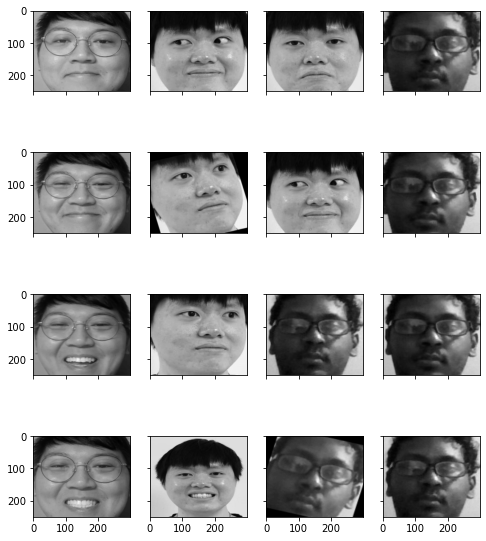

In [8]:
import matplotlib.pyplot as plt
 
fig, axes = plt.subplots(4,4,sharex=True,sharey=True,figsize=(8,10))
faceimages = list(faces.values())[-16:] # take last 16 images
for i in range(16):
    axes[i%4][i//4].imshow(faceimages[i], cmap="gray")
plt.show()

In [9]:
x_train = []
y_train = []
for key,val in faces.items():
    x_train.append(val.flatten())
    #x_train = val
    y_train.append(key.split("_")[0])

x_test = []
y_test = []
for key,val in test_faces.items():
    x_test.append(val.flatten())
    y_test.append(key.split("_")[0])

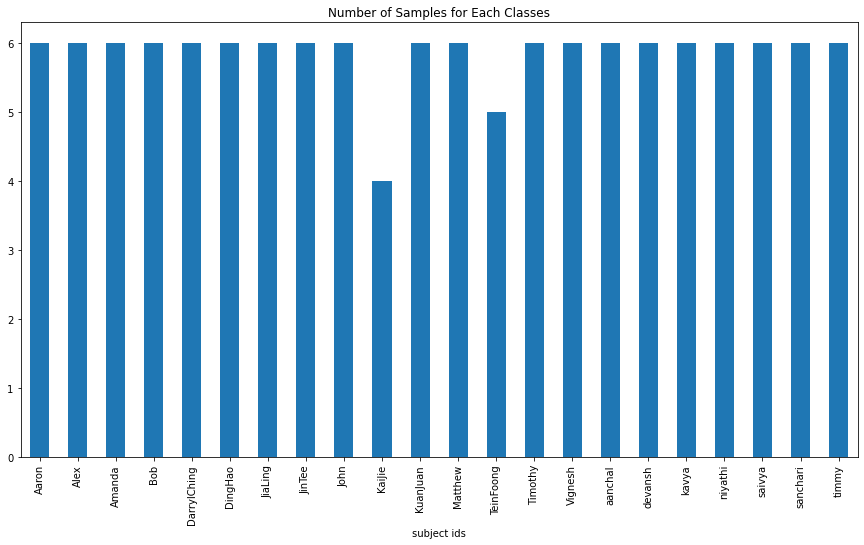

In [10]:
y_frame=pd.DataFrame()
y_frame['subject ids']=y_train
y_frame.groupby(['subject ids']).size().plot.bar(figsize=(15,8),title="Number of Samples for Each Classes")

In [11]:
new_y_train = []
for name in y_train:
    new_string = name.replace("aanchal", "0").replace("Aaron", "1").replace("Alex", "2").replace("Amanda", "3").replace("Bob", "4").replace("DarrylChing", "5").replace("devansh", "6").replace("DingHao", "7").replace("JiaLing", "8").replace("JinTee", "9").replace("John", "10").replace("KaiJie", "11").replace("kavya", "12").replace("KuanJuan", "13").replace("Matthew", "14").replace("niyathi", "15").replace("saivya", "16").replace("sanchari", "17").replace("TeinFoong", "18").replace("timmy", "19").replace("Timothy", "20").replace("Vignesh", "21")
    new_y_train.append(new_string)
    
new_y_test = []
for name in y_test:
    new_string = name.replace("aanchal", "0").replace("Aaron", "1").replace("Alex", "2").replace("Amanda", "3").replace("Bob", "4").replace("DarrylChing", "5").replace("devansh", "6").replace("DingHao", "7").replace("JiaLing", "8").replace("JinTee", "9").replace("John", "10").replace("KaiJie", "11").replace("kavya", "12").replace("KuanJuan", "13").replace("Matthew", "14").replace("niyathi", "15").replace("saivya", "16").replace("sanchari", "17").replace("TeinFoong", "18").replace("timmy", "19").replace("Timothy", "20").replace("Vignesh", "21")
    new_y_test.append(new_string)

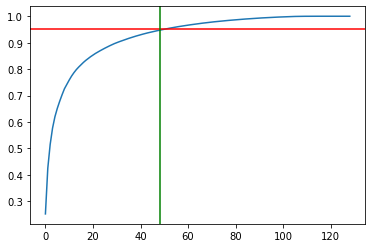

In [12]:
# Finding n_components
pca = PCA().fit(x_train) #n_components = 0.95
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(y=0.95, color='r', linestyle='-')
plt.axvline(x=48, color='g', linestyle='-') #40
plt.show()
#print(pca.explained_variance_ratio_)

In [13]:
x_train = np.array(x_train)
x_test = np.array(x_test)

In [14]:
target = []
for x in new_y_train:
    target.append(int(x))
print("unique target number:",np.unique(target))

unique target number: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]


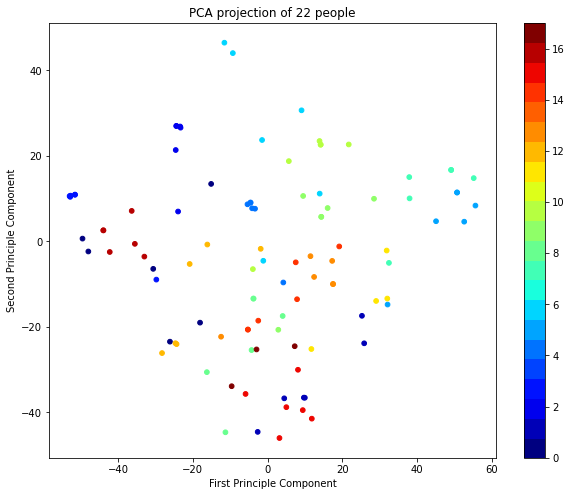

In [15]:
#target = np.array(target)
from sklearn.decomposition import PCA
pca=PCA(n_components=48)
pca.fit(x_train)
X_pca=pca.transform(x_train)

number_of_people=22
index_range=103
fig=plt.figure(figsize=(10,8))
ax=fig.add_subplot(1,1,1)
scatter=ax.scatter(X_pca[:index_range,0],
            X_pca[:index_range,1], 
            c=target[:index_range],
            s=22,
           cmap=plt.get_cmap('jet', number_of_people)
          )

ax.set_xlabel("First Principle Component")
ax.set_ylabel("Second Principle Component")
ax.set_title("PCA projection of {} people".format(number_of_people))

fig.colorbar(scatter)

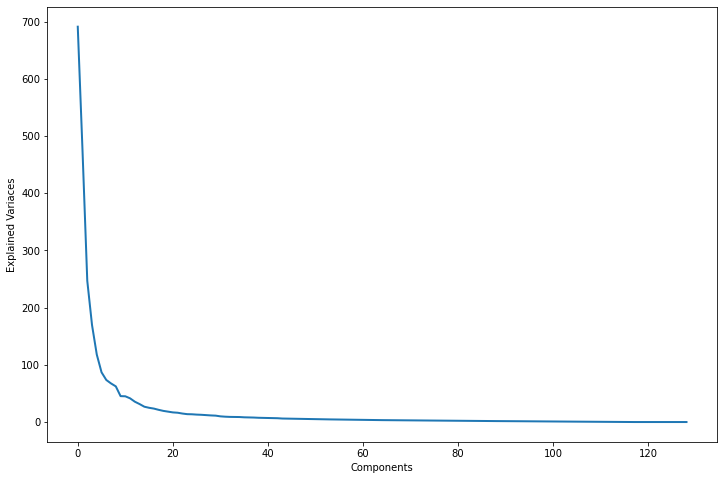

In [16]:
pca=PCA()
pca.fit(x_train)

plt.figure(1, figsize=(12,8))

plt.plot(pca.explained_variance_, linewidth=2)
 
plt.xlabel('Components')
plt.ylabel('Explained Variaces')
plt.show()

In [17]:
n_components=48
pca=PCA(n_components=n_components, whiten=True)
pca.fit(x_train)
X_train_pca=pca.transform(x_train)
X_test_pca=pca.transform(x_test)

In [18]:
y_train = np.array(new_y_train)
y_test = np.array(new_y_test)
print(X_train_pca.shape)
print(y_train.shape)
print(X_test_pca.shape)
print(y_test.shape)

from tensorflow.keras.utils import to_categorical

y_train=to_categorical(y_train,22)
y_test=to_categorical(y_test,22)


(129, 48)
(129,)
(22, 48)
(22,)


In [19]:
from keras.models import Sequential
from keras.layers import Dense, Activation
from keras.callbacks import ReduceLROnPlateau
from keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from keras import regularizers

In [26]:
model=Sequential()
model.add(Dense(256, activation='relu', input_dim=48))
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.05))
model.add(Dense(22, activation='softmax'))

epochs=120
batch_size=128
#red_lr=ReduceLROnPlateau(monitor='val_acc', factor=0.1, min_delta=0.0001, patience=2, verbose=1)
model.compile(optimizer=Adam(learning_rate=1e-2),loss='categorical_crossentropy',metrics=['accuracy'])

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 256)               12544     
                                                                 
 dropout_9 (Dropout)         (None, 256)               0         
                                                                 
 dense_13 (Dense)            (None, 128)               32896     
                                                                 
 dropout_10 (Dropout)        (None, 128)               0         
                                                                 
 dense_14 (Dense)            (None, 128)               16512     
                                                                 
 dropout_11 (Dropout)        (None, 128)               0         
                                                                 
 dense_15 (Dense)            (None, 22)               

In [27]:
History = model.fit(X_train_pca,y_train, epochs = epochs, validation_data = (X_test_pca,y_test),batch_size=batch_size, verbose = 1)

Epoch 1/120
2/2 [==============================] - 1s 136ms/step - loss: 3.1480 - accuracy: 0.0465 - val_loss: 2.7469 - val_accuracy: 0.2727
Epoch 2/120
2/2 [==============================] - 0s 28ms/step - loss: 2.5549 - accuracy: 0.3101 - val_loss: 2.2530 - val_accuracy: 0.5455
Epoch 3/120
2/2 [==============================] - 0s 28ms/step - loss: 1.9810 - accuracy: 0.3721 - val_loss: 1.8645 - val_accuracy: 0.5909
Epoch 4/120
2/2 [==============================] - 0s 26ms/step - loss: 1.4222 - accuracy: 0.6357 - val_loss: 1.5589 - val_accuracy: 0.7273
Epoch 5/120
2/2 [==============================] - 0s 29ms/step - loss: 1.0498 - accuracy: 0.7519 - val_loss: 1.6509 - val_accuracy: 0.5455
Epoch 6/120
2/2 [==============================] - 0s 31ms/step - loss: 1.0420 - accuracy: 0.7054 - val_loss: 1.2954 - val_accuracy: 0.5455
Epoch 7/120
2/2 [==============================] - 0s 28ms/step - loss: 0.8444 - accuracy: 0.7519 - val_loss: 1.0744 - val_accuracy: 0.5909
Epoch 8/120
2/2 [==

2/2 [==============================] - 0s 27ms/step - loss: 0.0082 - accuracy: 0.9922 - val_loss: 0.7407 - val_accuracy: 0.9091
Epoch 60/120
2/2 [==============================] - 0s 25ms/step - loss: 9.5386e-04 - accuracy: 1.0000 - val_loss: 0.7356 - val_accuracy: 0.9091
Epoch 61/120
2/2 [==============================] - 0s 25ms/step - loss: 0.0052 - accuracy: 1.0000 - val_loss: 0.7421 - val_accuracy: 0.9545
Epoch 62/120
2/2 [==============================] - 0s 25ms/step - loss: 0.0493 - accuracy: 0.9922 - val_loss: 0.7533 - val_accuracy: 0.9545
Epoch 63/120
2/2 [==============================] - 0s 26ms/step - loss: 0.0026 - accuracy: 1.0000 - val_loss: 0.7570 - val_accuracy: 0.9545
Epoch 64/120
2/2 [==============================] - 0s 26ms/step - loss: 0.0034 - accuracy: 1.0000 - val_loss: 0.7496 - val_accuracy: 0.9545
Epoch 65/120
2/2 [==============================] - 0s 26ms/step - loss: 3.2883e-04 - accuracy: 1.0000 - val_loss: 0.7444 - val_accuracy: 0.9545
Epoch 66/120
2/2 [

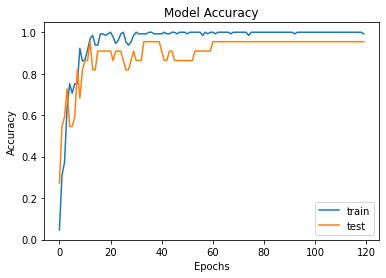

In [28]:
#Lower accuracy due to less data
plt.plot(History.history['accuracy'])
plt.plot(History.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'test'])
plt.show()

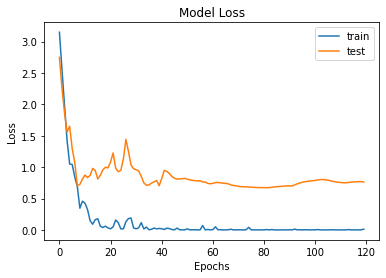

In [29]:
plt.plot(History.history['loss'])
plt.plot(History.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'test'])
plt.show()

In [30]:
# #Saving the model
# model.save('Models/face_recog_1')

In [31]:
#preparing labels
test_names_temp = np.array(list(test_faces.keys()))
test_names = []
for name in test_names_temp:
    test_names.append(name.split('_')[0])

In [32]:
# define a video capture object 
faceCascade=cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_alt2.xml")
vid = cv2.VideoCapture(0) 
if not vid.isOpened():
    print("Cannot open camera")
    exit()

    # We need to set resolutions. So, convert them from float to integer.
frame_width = int(vid.get(3))
frame_height = int(vid.get(4))
size = (frame_width, frame_height)
# Below VideoWriter object will create a frame of above defined The output is stored in 'filename.avi' file.
vid_result = cv2.VideoWriter('Face_recog_DL.avi', 
                         cv2.VideoWriter_fourcc(*'MJPG'),
                         30, size)
while(True): 
    # Capture the video frame by frame
    ret, frame = vid.read()
    
    if ret == True: 
    
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        #For in plane rotation
        for angle in [0, -25, 25]:
            rimg = rotate_image(frame, angle)
            faces = faceCascade.detectMultiScale(
                    rimg,
                    scaleFactor=1.3, #1.1
                    minNeighbors=4,#4
                    minSize=(50, 50), #30x30
                    flags=cv2.CASCADE_SCALE_IMAGE
                )

            detected_arr = []
            if len(faces):
                for detected_face in faces:
                    det_face = [rotate_point(detected_face, frame, -angle)] #coordinates
                    detected_arr.append(det_face)
                break

        for det_face in detected_arr:
            for (x, y, w, h) in det_face:
                #Pre processing
                img = gray[y:y+h, x:x+w]
                img = cv2.resize(img, dim)
                #Normalization is important in PCA since it is a variance maximizing exercise. It projects your original data onto directions which maximize the variance
                img = cv2.normalize(img, None, alpha=0,beta=200, norm_type=cv2.NORM_MINMAX)
                # convert from integers to floats
                img = img.astype('float32')
                # normalize to the range 0-1
                img /= 255.0

                img = img.flatten()
                img = np.array([img])
                img = pca.transform(img)

                #Input into neural net
                result = model.predict(img)
                index = result.argmax()
                label = test_names[index]

                #detecting unknown faces
    #             if euclidean_distance[best_match] > 35:
    #                 facelabel[best_match] = "Unknown"
                cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
                cv2.putText(frame, label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (36,255,12), 2)
            
        vid_result.write(frame)
        # Display the resulting frame 
        cv2.imshow('',frame) 
            
        if cv2.waitKey(1) & 0xFF == ord('s'):
            break
    else:
        break     

# After the loop release the cap object 
vid.release() 
vid_result.release()
# Destroy all the windows 
cv2.destroyAllWindows() 

In [42]:
count = 0
test_folder = r'..\data\test_DL'
test_faces = {}
pred = []
for filename in os.listdir(test_folder):
    
    #Pre processing
    original_img = cv2.imread(os.path.join(test_folder,filename),0) #reads as grayscale
    img = face_detection(original_img)
    img = cv2.resize(img, dim)
    img = cv2.normalize(img, None, alpha=0,beta=200, norm_type=cv2.NORM_MINMAX)
    # convert from integers to floats
    img = img.astype('float32')
    # normalize to the range 0-1
    img /= 255.0
    img = img.flatten()
    img = np.array([img])
    img = pca.transform(img)
    
    #Input into neural net
    result = model.predict(img)
    index = result.argmax()
    value = max(result[0])
#     if value < 0.9:
#         label = 'Unknown'
    
    label = test_names[index]
    
    print("Best match for %s is %s with probability %f" % (filename, label, value))

Best match for aanchal_6.jpg is aanchal with probability 0.999905
Best match for Aaron_6.jpg is Aaron with probability 0.999995
Best match for Alex_6.jpg is Alex with probability 0.999494
Best match for Amanda_6.jpg is Amanda with probability 0.999998
Best match for Bob_6.jpg is Bob with probability 0.668260
Best match for DarrylChing_6.jpg is DarrylChing with probability 0.999732
Best match for devansh_6.jpeg is devansh with probability 0.999577
Best match for DingHao_6.jpg is DingHao with probability 0.999840
Best match for JiaLing_6.jpg is JiaLing with probability 0.974194
Best match for JinTee_6.jpg is JinTee with probability 0.999997
Best match for John_6.jpg is John with probability 0.999989
Best match for KaiJie_6.jpg is saivya with probability 0.816176
Best match for kavya_6.jpeg is kavya with probability 1.000000
Best match for KuanJuan_6.jpg is KuanJuan with probability 0.999499
Best match for Matthew_6.jpg is Matthew with probability 0.986291
Best match for niyathi_6.jpeg is